In [24]:
import numpy as np
import torch
import torch.nn as nn
import itertools
from torch.autograd import Variable

## Forward Euler Method
$$
y_{n+1} = y_n + h \, f(t_n, y_n)
$$

## Mackey-Glass equation
$$
\frac{dx(t)}{dt} = \beta \frac{x(t - \tau)}{1 + [x(t - \tau)]^n} - \gamma x(t)
$$

### combine together
$$
x_{t+1} = x_t + dt \left( \beta \frac{x_{t - \tau}}{1 + [x_{t - \tau}]^n} - \gamma x_t \right)
$$


In [25]:
# mackey-glass implementation

beta = 0.2
tau = 17
gamma = 0.1
n = 10
dt = 0.1

delay = int(tau / dt)
init_value = 1.2
T = 1000
num_steps = int(T/dt)

x = np.zeros(num_steps)
x[:delay] = init_value
time = np.arange(num_steps) * dt

for t in range(delay, num_steps-1):
    feedback = (beta * x[t-delay]) / (1 + (x[t-delay])**n)
    x[t+1] = x[t] + dt * (feedback - gamma*x[t])


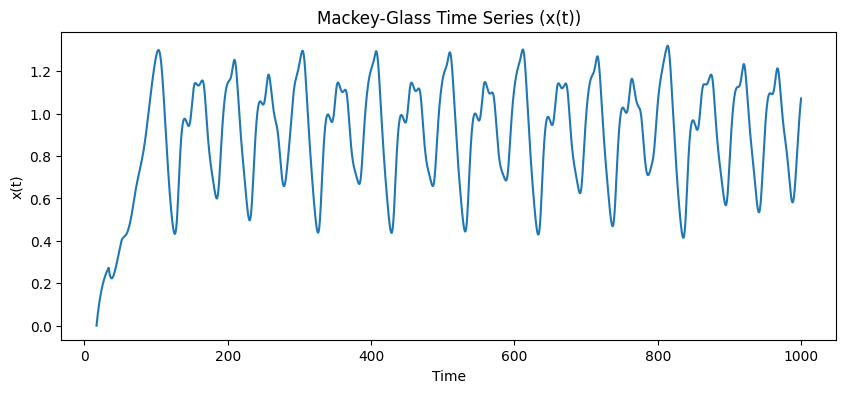

In [26]:
#plot

time_pos = time[delay:]
x_pos = x[delay:]

plt.figure(figsize=(10, 4))
plt.plot(time_pos, x_pos)
plt.title("Mackey-Glass Time Series (x(t))")
plt.xlabel("Time")
plt.ylabel("x(t)")

plt.show()

## Regression for mackey-glass

$$x(t)=f(x(t−6), x(t−12), x(t−18), x(t−24))$$
- So there are four inputs for the function f and we are trying to find the funcitonality using regression
- In the following piece of code we are trying to find each element (y) and all the elements in the past according to the equation we discussed
    - exmaple:
    - y[0] = x_pos[24]
    - x[0] = [x_pos[0], x_pos[6], x_pos[12], x_pos[18]]
    - this means for y[i] the valued needed are the elements of x[i]

In [27]:
lags = [24, 18, 12, 6]  # classic lags
X, y = [], []

for t in range(max(lags), len(x_pos)):
    X.append([x_pos[t - lag] for lag in lags])
    y.append(x_pos[t])

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32).reshape(-1, 1)

# convert to PyTorch tensors
X_tensor = torch.from_numpy(X)
y_tensor = torch.from_numpy(y)

## Memebership function creation
- The following code is for building the initial state of the mf's
- centers row each is an input and the values are the center of each memebership function
- spreads is the init width of each mf
- forward method:
- - Takes a batch of input samples
  - Computes membership degrees for all inputs across all MFs using Gaussian bell functions
  - Returns a tensor of shape (batch_size, n_inputs, n_mfs) ready for the rule layer

In [28]:
class GaussianMF(nn.Module):
    def __init__(self, n_inputs=4, n_mfs=3):
        super().__init__()
        self.n_inputs = n_inputs
        self.n_mfs = n_mfs
        
        # Initialize centers and spreads (premise parameters) as learnable
        # Shape: (n_inputs, n_mfs)
        self.centers = nn.Parameter(torch.randn(n_inputs, n_mfs))
        self.spreads = nn.Parameter(torch.ones(n_inputs, n_mfs) * 0.5)  # start with some spread

    def forward(self, x):
        """
        x: shape (batch_size, n_inputs)
        Returns: membership degrees, shape (batch_size, n_inputs, n_mfs)
        """
        x_expanded = x.unsqueeze(2)  # (batch_size, n_inputs, 1)
        c_expanded = self.centers.unsqueeze(0)  # (1, n_inputs, n_mfs)
        s_expanded = self.spreads.unsqueeze(0)  # (1, n_inputs, n_mfs)
        
        # Gaussian membership function
        mu = torch.exp(-((x_expanded - c_expanded) ** 2) / (2 * s_expanded ** 2))
        return mu  # (batch_size, n_inputs, n_mfs)

## calculation part

In [29]:
## neuro fuzzy implementation

class ANFIS(nn.Module):
    def __init__(self, n_inputs=4, n_mfs=3):
        super().__init__()
        self.n_inputs = n_inputs
        self.n_mfs = n_mfs
        self.n_rules = n_mfs ** n_inputs
        
        # Membership function layer
        self.mf_layer = GaussianMF(n_inputs, n_mfs)
        
        # Consequent parameters: one linear function per rule
        # Shape: (n_rules, n_inputs + 1), last column is bias
        self.consequents = nn.Parameter(torch.randn(self.n_rules, n_inputs + 1))
        
        # Precompute all rule MF index combinations
        self.rule_indices = torch.tensor(
            list(itertools.product(range(n_mfs), repeat=n_inputs))
        )  # shape (n_rules, n_inputs)

    def forward(self, x):
        batch_size = x.shape[0]
        
        # Compute membership degrees
        # fuzzification
        mu = self.mf_layer(x)  # (batch, n_inputs, n_mfs)
        
        # Compute firing strengths for all rules
        # Rule firing (AND combination)
        mu_expanded = mu.unsqueeze(1).expand(-1, self.n_rules, -1, -1)
        rule_idx_expanded = self.rule_indices.unsqueeze(0).unsqueeze(-1)
        firing_strengths = torch.gather(mu_expanded, dim=3, index=rule_idx_expanded).squeeze(3)
        w = torch.prod(firing_strengths, dim=2)  # (batch, n_rules)

        # Normalization
        w_norm = w / w.sum(dim=1, keepdim=True)    # normalized firing strengths
        
        # Compute consequent outputs
        # Consequent (rule output)
        X_expanded = x.unsqueeze(1).expand(-1, self.n_rules, -1)  # (batch, n_rules, n_inputs)
        y_r = torch.sum(X_expanded * self.consequents[:, :-1], dim=2) + self.consequents[:, -1]  # (batch, n_rules)
        
        # Weighted sum over rules
        # Defuzzification (aggregation)
        y_pred = torch.sum(w_norm * y_r, dim=1, keepdim=True)  # (batch, 1)
        return y_pred

In [ ]:
# ------------------------------------------
# TRAIN 1: SGD
# ------------------------------------------
model_sgd = ANFIS(n_inputs=4, n_mfs=3)
loss_fn = nn.MSELoss()
optimizer_sgd = torch.optim.SGD(model_sgd.parameters(), lr=0.001, momentum=0.9)

for epoch in range(1500):
    optimizer_sgd.zero_grad()
    y_pred_sgd = model_sgd(X_tensor)
    loss = loss_fn(y_pred_sgd, y_tensor)
    loss.backward()
    optimizer_sgd.step()

# Convert to numpy
y_pred_sgd_np = y_pred_sgd.detach().numpy()

In [35]:
# ------------------------------------------
# TRAIN 2: Adam
# ------------------------------------------
model_adam = ANFIS(n_inputs=4, n_mfs=3)
optimizer_adam = torch.optim.Adam(model_adam.parameters(), lr=1e-3)

for epoch in range(1000):
    optimizer_adam.zero_grad()
    y_pred_adam = model_adam(X_tensor)
    loss = loss_fn(y_pred_adam, y_tensor)
    loss.backward()
    optimizer_adam.step()

y_pred_adam_np = y_pred_adam.detach().numpy()

The cost of prediction using adam only:  0.0016935136


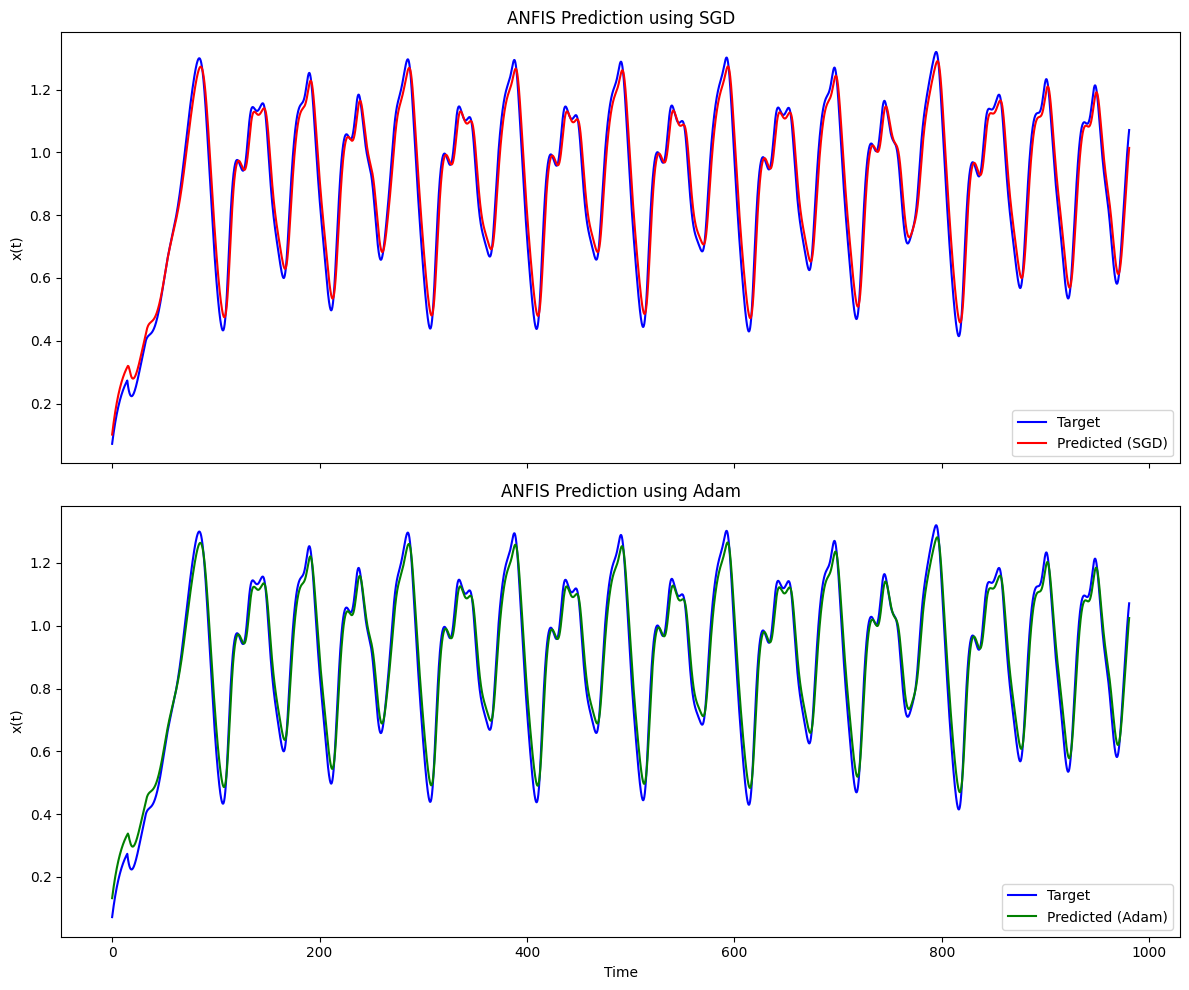

In [39]:
y_true_np = y_tensor.numpy()
time_pred = np.arange(len(y_true_np)) * dt


# print cost
mse_cost = np.mean((y_true_np - y_pred_adam_np)**2)
print("The cost of prediction using adam only: ", mse_cost)

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# SGD plot
axes[0].plot(time_pred, y_true_np, label='Target', color='blue')
axes[0].plot(time_pred, y_pred_sgd_np, label='Predicted (SGD)', color='red')
axes[0].set_title("ANFIS Prediction using SGD")
axes[0].set_ylabel("x(t)")
axes[0].legend()

# Adam plot
axes[1].plot(time_pred, y_true_np, label='Target', color='blue')
axes[1].plot(time_pred, y_pred_adam_np, label='Predicted (Adam)', color='green')
axes[1].set_title("ANFIS Prediction using Adam")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("x(t)")
axes[1].legend()

plt.tight_layout()
plt.show()